# Dataset Overview
It is a synthetic dataset specifically designed for exploring financial behavior patterns, building machine learning models, and testing anomaly detection techniques.
Here is a breakdown of what the dataset contains and how it is structured.
### Dataset Overview

- **Size:** 2,512 transaction records.
    
- **Features:** 16 columns covering transaction details, customer demographics, and technical metadata.
    
- **Purpose:** The data is simulated to represent a variety of banking scenarios. It is ideal for training models to flag high-risk transactions or spotting unusual patterns (like a sudden spike in login attempts or unexpected merchant activity).
    
    
### The Data Dictionary

The 16 columns can be broken down into four logical categories:

#### 1. Core Transaction Details

These columns describe the specific financial action taking place.


- **TransactionAmount:** The monetary value of the transaction.
    
    
- **TransactionType:** Categorical field indicating if it was a 'Credit' or 'Debit'.
    
    
- **TransactionDate:** The exact timestamp of the transaction.
      
- **Channel:** How the transaction was performed (e.g., _Online_, _ATM_, _Branch_).
    
        
- **TransactionDuration:** How long the transaction took to process, measured in seconds.
    
#### 2. Customer & Account Context

These columns help establish a baseline for what is "normal" for a given user.

  

- **CustomerAge:** The age of the account holder.
    
      
    
- **CustomerOccupation:** The account holder's profession (e.g., _Doctor_, _Student_, _Retired_), which often correlates with spending capacity.
    
      
    
- **AccountBalance:** The remaining balance in the account immediately after the transaction.
    
      
    
- **PreviousTransactionDate:** The timestamp of the account's last transaction (useful for calculating transaction frequency/velocity).
    
      
    

#### 3. Security & Technical Flags

These features are heavily relied upon for detecting anomalies and potential fraud.

  

- **Location:** The U.S. city where the transaction occurred. A sudden location jump often flags fraud.
    
      
    
- **IP Address:** The IPv4 address associated with the transaction.
    
      
    
- **DeviceID:** An alphanumeric ID for the device used. Multiple devices on one account can trigger alerts.
    
      
    
- **LoginAttempts:** The number of failed login attempts before the transaction succeeded. High numbers strongly indicate account takeover attempts.
    
      
    

#### 4. Identifiers

Unique keys used to link the data or track repeat behavior.

  

- **TransactionID:** Unique ID for the specific event.
    
      
    
- **AccountID:** Unique ID for the user's account.
    
      
    
- **MerchantID:** Unique ID for the merchant receiving the funds. (Useful for spotting compromised vendors).

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv(r'D:\JEBEZ\00 - Placement\CTS\bank-fraud-detection\data\original.csv')
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [43]:
df.shape
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


In [46]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})
missing_df

,Missing Values,Percentage
TransactionID,0,0.0
AccountID,0,0.0
TransactionAmount,0,0.0
TransactionDate,0,0.0
TransactionType,0,0.0
Location,0,0.0
DeviceID,0,0.0
IP Address,0,0.0
MerchantID,0,0.0
Channel,0,0.0


In [47]:
# Duplicate rows
print(df.duplicated().sum())

0


In [48]:
# Column type separation
id_cols = ['TransactionID', 'AccountID']
date_cols = ['TransactionDate', 'PreviousTransactionDate']

# Convert to datetime
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Identify numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
Categorical columns: ['TransactionID', 'AccountID', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation']


# Exploratory Data Analysis

## Univariate Analysis

### Numerical Features

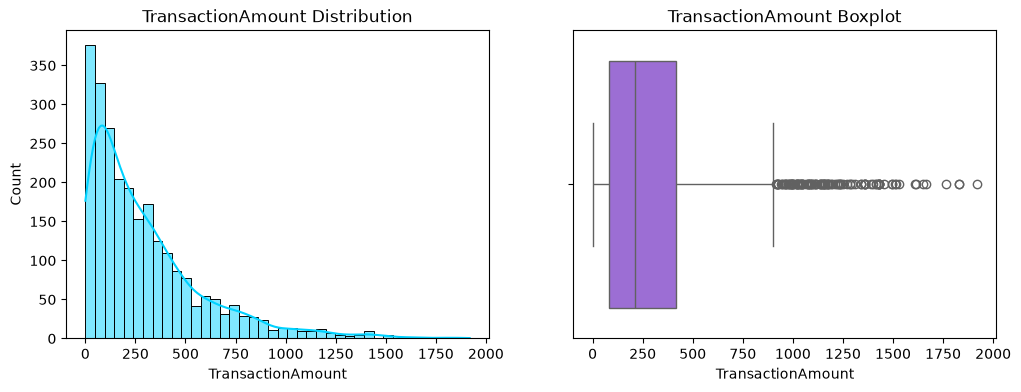

count    2512.000000
mean      297.593778
std       291.946243
min         0.260000
25%        81.885000
50%       211.140000
75%       414.527500
max      1919.110000
Name: TransactionAmount, dtype: float64
Skewness: 1.74, Kurtosis: 3.64



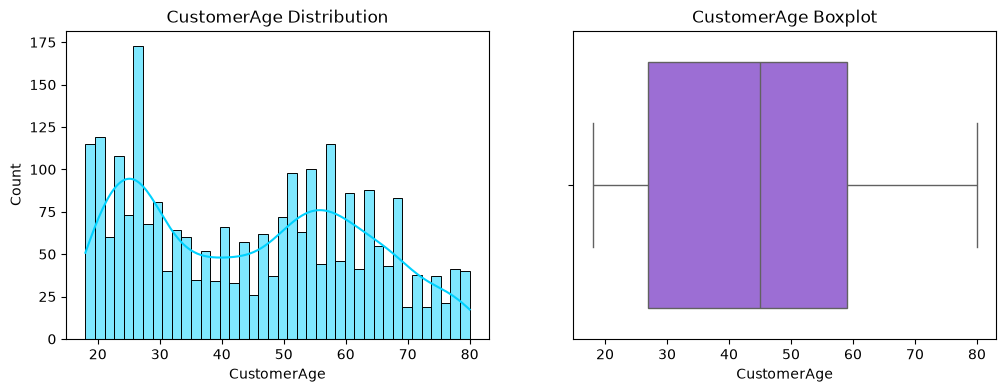

count    2512.000000
mean       44.673965
std        17.792198
min        18.000000
25%        27.000000
50%        45.000000
75%        59.000000
max        80.000000
Name: CustomerAge, dtype: float64
Skewness: 0.15, Kurtosis: -1.22



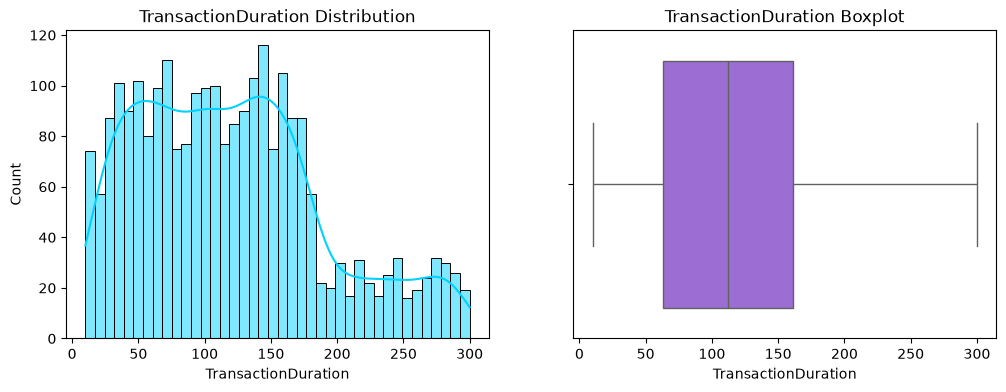

count    2512.000000
mean      119.643312
std        69.963757
min        10.000000
25%        63.000000
50%       112.500000
75%       161.000000
max       300.000000
Name: TransactionDuration, dtype: float64
Skewness: 0.60, Kurtosis: -0.26



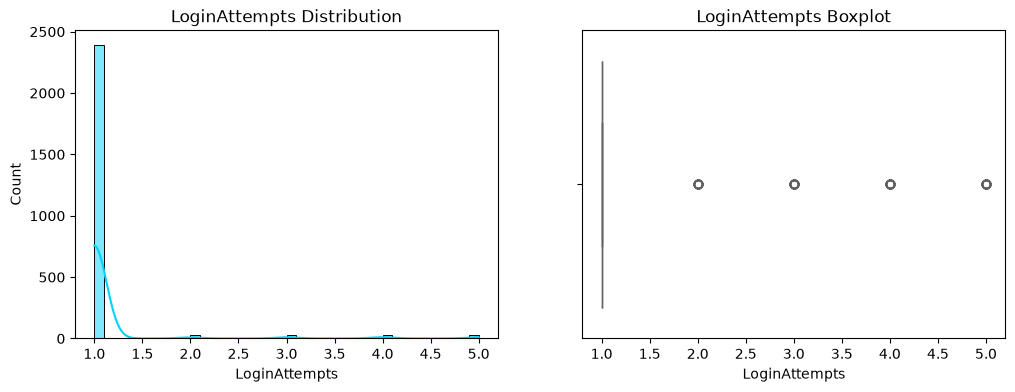

count    2512.000000
mean        1.124602
std         0.602662
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: LoginAttempts, dtype: float64
Skewness: 5.17, Kurtosis: 26.67



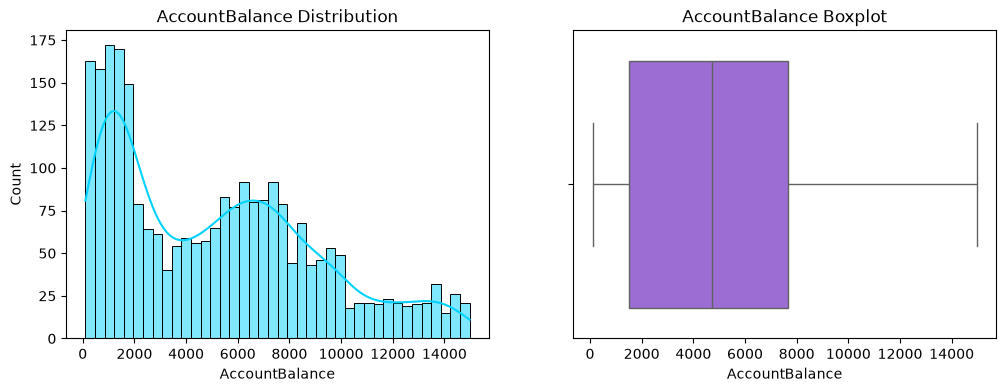

count     2512.000000
mean      5114.302966
std       3900.942499
min        101.250000
25%       1504.370000
50%       4735.510000
75%       7678.820000
max      14977.990000
Name: AccountBalance, dtype: float64
Skewness: 0.60, Kurtosis: -0.56



In [49]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(df[col], kde=True, bins=40, ax=axes[0], color="#00D2FF")
    axes[0].set_title(f"{col} Distribution")
    sns.boxplot(x=df[col], ax=axes[1], color="#9B5DE5")
    axes[1].set_title(f"{col} Boxplot")
    plt.show()
    print(df[col].describe().T)
    print(f"Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}\n")

### Categorical Features

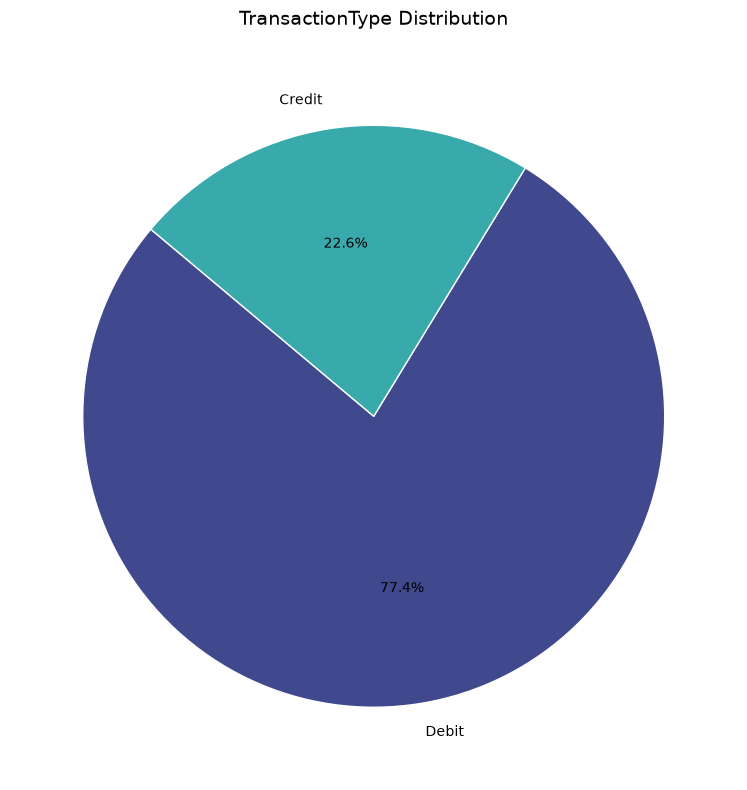

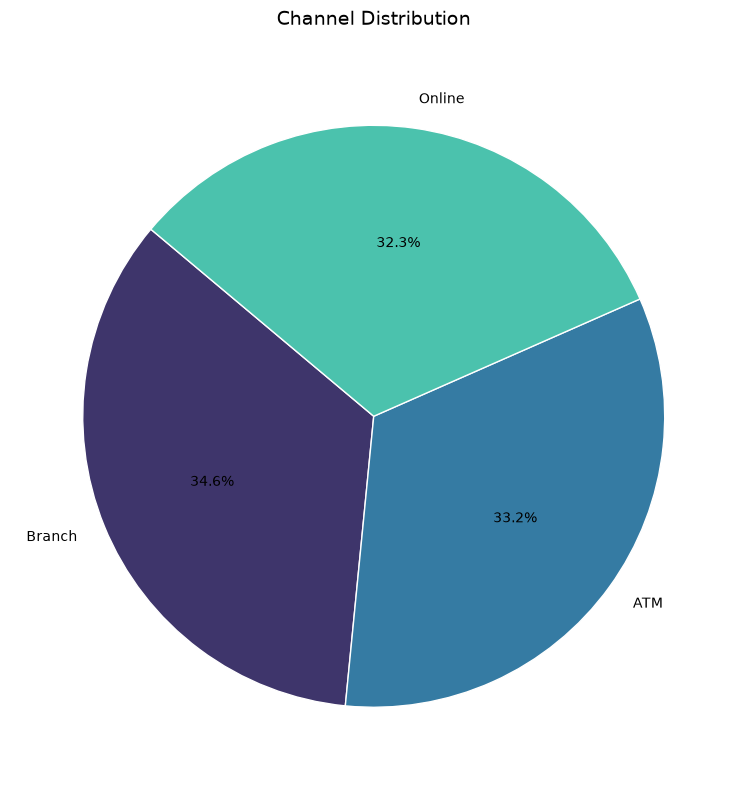

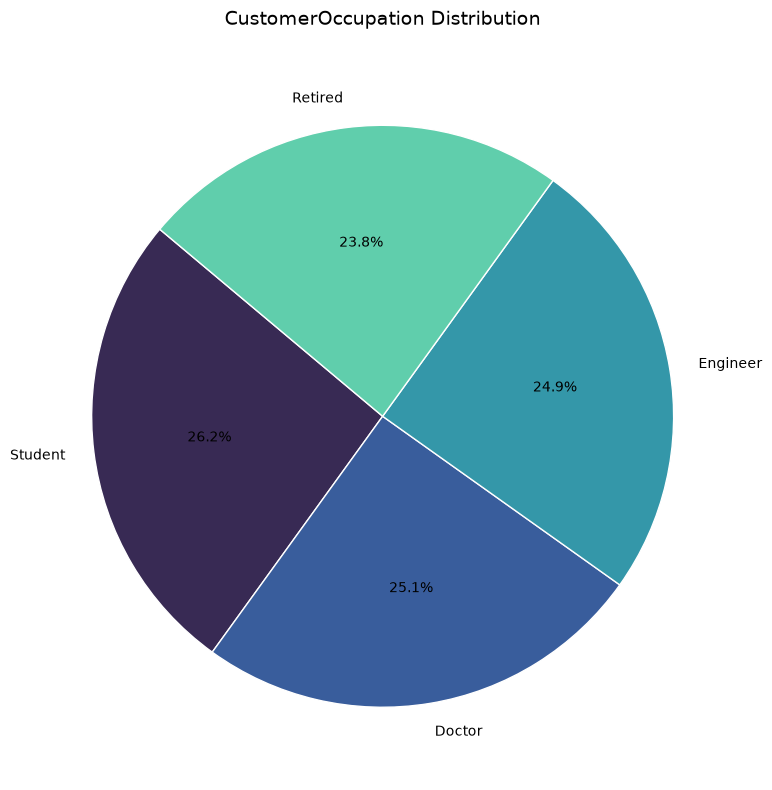

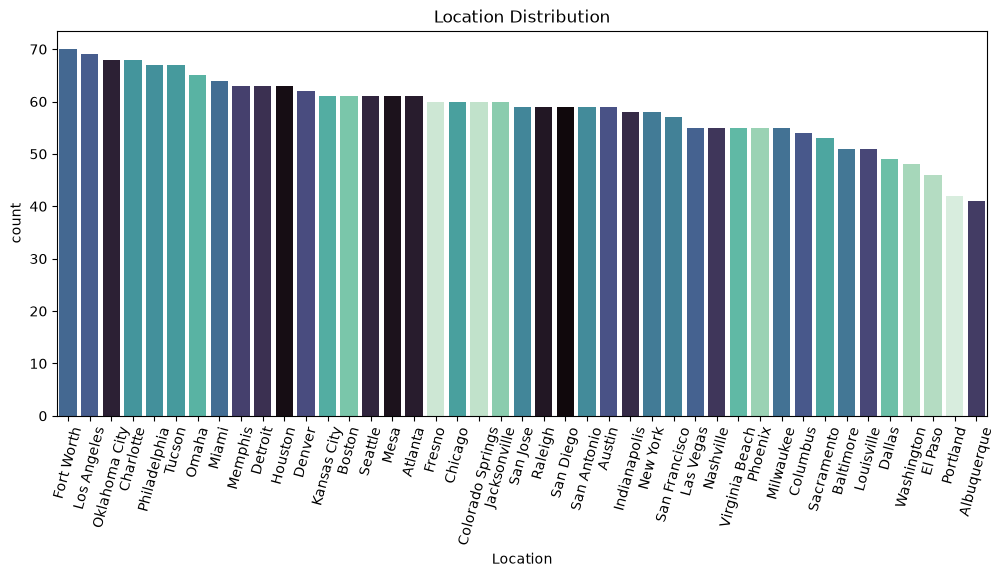

In [50]:
import matplotlib.pyplot as plt

cat_cols = ['TransactionType', 'Channel', 'CustomerOccupation']

for col in cat_cols:
    plt.figure(figsize=(8, 8))
    
    # 1. Get counts and labels
    counts = df[col].value_counts()
    
    # 2. Get colors from the mako palette to match your original theme
    colors = sns.color_palette("mako", len(counts))
    
    # 3. Plot the pie chart
    plt.pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%',      # Displays percentage inside with 1 decimal place
        startangle=140,         # Rotates the start for better visual alignment
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}  # Adds clean separation lines
    )
    
    plt.title(f"{col} Distribution", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(12,5))
order = df['Location'].value_counts().index
sns.countplot(x=df['Location'], data=df,legend= False,hue = df['Location'], order=order, palette="mako")
plt.title(f"Location Distribution")
plt.xticks(rotation=75)
plt.show()

## Bivariate Analysis

Plotting account balance with Transaction amount against each other helps identify transactions that disproportionately drain an account

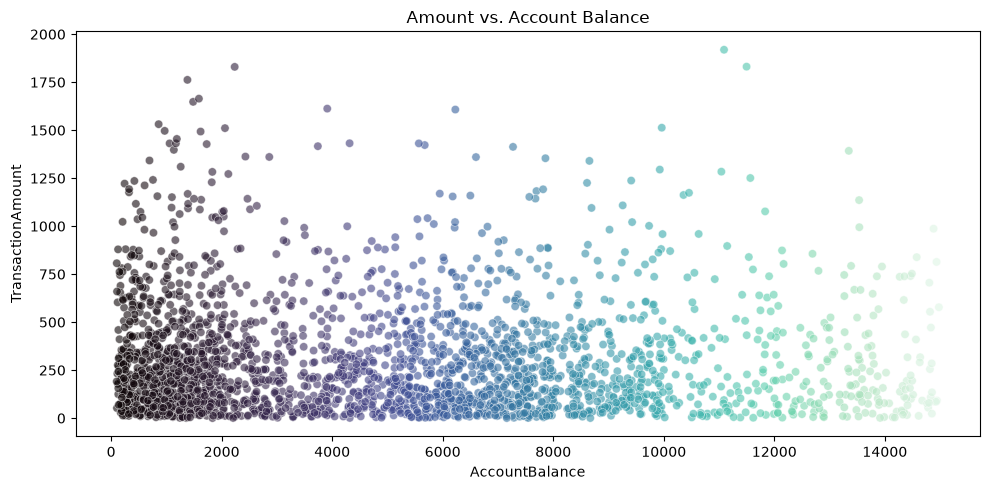

In [51]:
# 1. Account Balance vs Transaction Amount
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='AccountBalance',
    y='TransactionAmount',
    hue='AccountBalance',
    palette='mako',
    legend=False,
    alpha=0.6
)
plt.title("Amount vs. Account Balance")
plt.tight_layout()
plt.show()


Wealth doesn't dictate spend size

This plot perfectly illustrates why you should create a new column before training your model. By dividing TransactionAmount by AccountBalance, you can create a UtilizationRatio feature.

Since the dataset has a perfectly balanced occupation split, map the transaction amounts to these roles. A $10,000 transaction might sit exactly on the median for a "Doctor" but appear as an extreme outlier for a "Student".

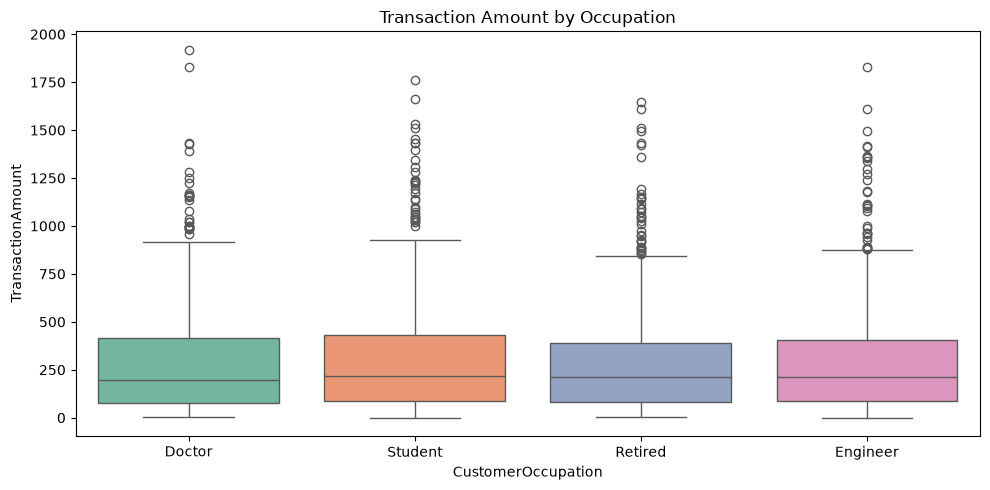

In [52]:
#Transaction Amount by Occupation
mako = sns.color_palette("mako", n_colors=df['CustomerOccupation'].nunique())
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='CustomerOccupation',
    y='TransactionAmount',
    hue='CustomerOccupation',
    palette='Set2',
    legend=False
)

plt.title("Transaction Amount by Occupation")
plt.tight_layout()
plt.show()


occupation has almost no correlation with transaction size. Hence Low Feature Importance for Amount Anomalies

This is where that long tail in the TransactionDuration distribution becomes useful. If a Branch transaction takes 300 seconds, that's normal. If an ATM transaction takes 300 seconds, the machine might have been tampered with or the card is being tested.

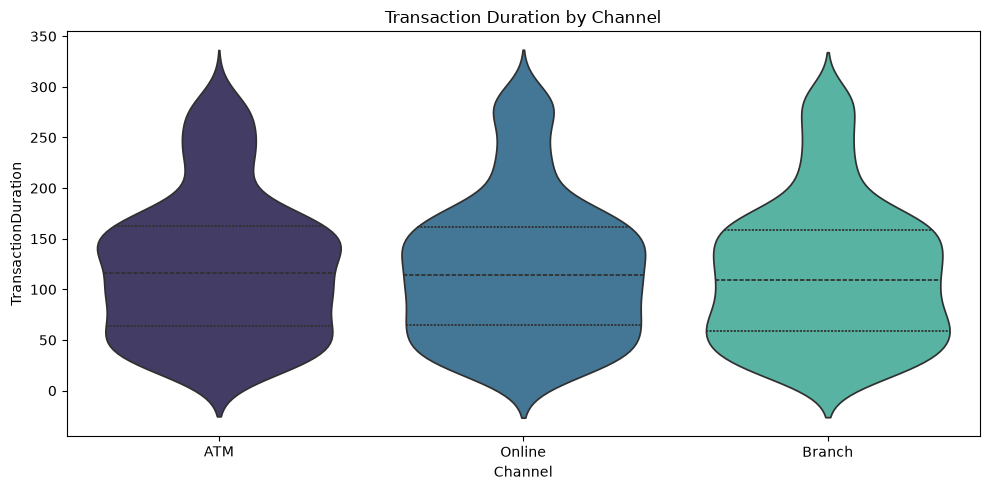

In [53]:

# 3. Transaction Duration by Channel
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x='Channel',
    y='TransactionDuration',
    hue='Channel',
    palette='mako',
    legend=False,
    inner='quartile'
)
plt.title("Transaction Duration by Channel")
plt.tight_layout()
plt.show()

In the real world, transaction duration is heavily dependent on the channel.  
A standard ATM withdrawal usually takes less than 60 seconds. An online transaction might take 30 to 90 seconds depending on 2FA (Two-Factor Authentication).  
A branch transaction, involving speaking to a teller, routinely takes several minutes.

This shows that it is a simulated dataset

We found that occupation doesn't dictate spending size by the Transaction Amount by Occupation plot. So we are trying to find other meaningful relationships 

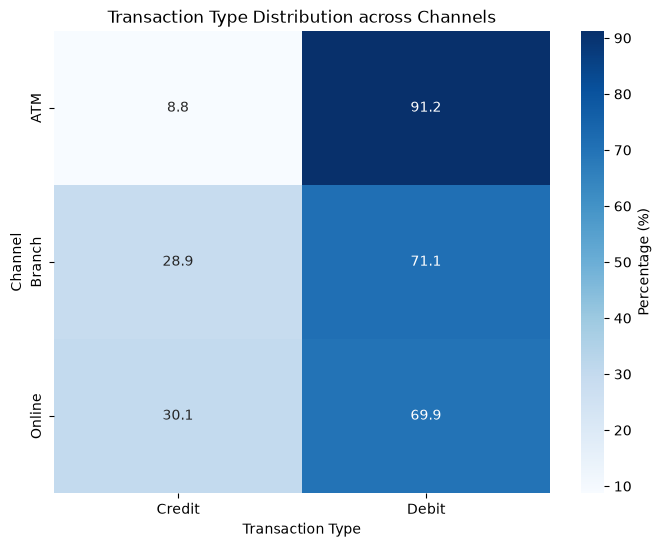

In [54]:
# Create a cross-tabulation of Channel vs. TransactionType, normalized by row to show percentages
channel_type_ct = pd.crosstab(df['Channel'], df['TransactionType'], normalize='index') * 100

plt.figure(figsize=(8, 6))
# Annotate the heatmap to show the exact percentage in each cell
sns.heatmap(channel_type_ct, annot=True, fmt=".1f", cmap="Blues", 
            cbar_kws={'label': 'Percentage (%)'})

plt.title("Transaction Type Distribution across Channels")
plt.xlabel("Transaction Type")
plt.ylabel("Channel")
plt.show()

This distribution kind of mimics the real-world. 

Given the bimodal age distribution we saw earlier, check if spending behaviors map predictably to those two age clusters.

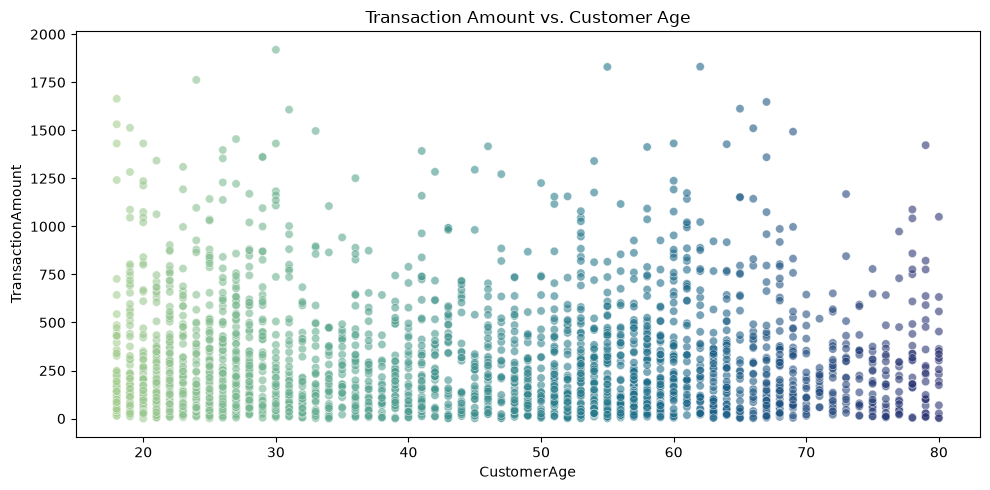

In [55]:
# 4. Transaction Amount vs. Customer Age
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='CustomerAge',
    y='TransactionAmount',
    hue='CustomerAge',
    palette='crest',
    legend=False,
    alpha=0.6
)
plt.title("Transaction Amount vs. Customer Age")
plt.tight_layout()
plt.show()

In real-world financial data, age is almost always correlated with spending behavior. Younger people have lower credit limits and smaller transaction amount



In this plot, age has absolutely zero correlation with transaction size. Just like the CustomerOccupation and TransactionDuration distributions, this perfect independence is a massive flashing indicator of a synthetically generated dataset where variables were created in silos using separate probability distributions.

Are unusually large transactions taking suspiciously little time to process? Automated bot behavior often executes large transfers in fractions of a second compared to a human user.

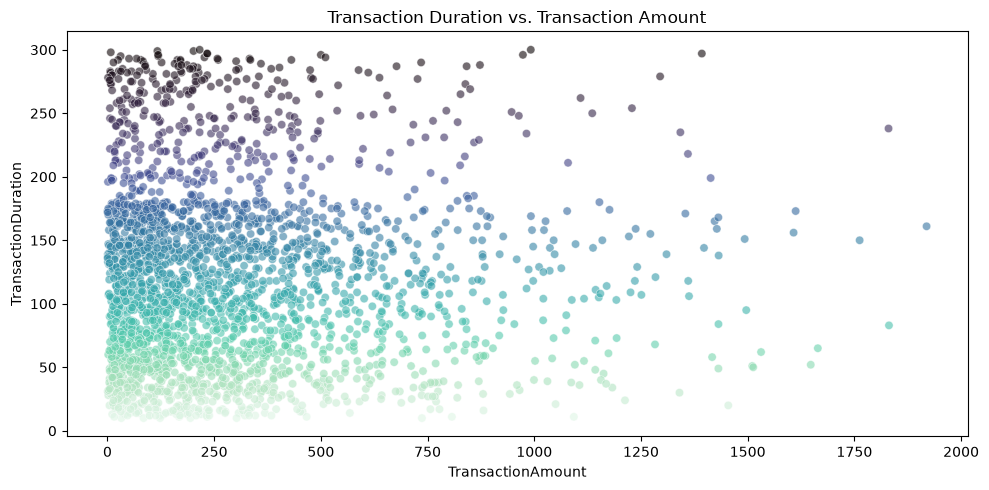

In [56]:
# Transaction Duration vs. Transaction Amount
# to check high speed, high value anamolies

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='TransactionAmount',
    y='TransactionDuration',
    hue='TransactionDuration',
    palette='mako_r',
    legend=False,
    alpha=0.6
)
plt.title("Transaction Duration vs. Transaction Amount")
plt.tight_layout()
plt.show()

In a real-world setting, we might expect a slight correlation here. For example, exceptionally large transfers might require additional security checks. Conversely, automated bot attacks might execute maximum-value transfers in fractions of a second.

In this plot, duration and amount are completely uncorrelated. Showing that this is a synthetically generated data.

An ATM withdrawal has hard physical limits and typical human behaviors associated with it, whereas an Online transfer has different ceilings.We need to verify if the model needs different anomaly thresholds for different channels.

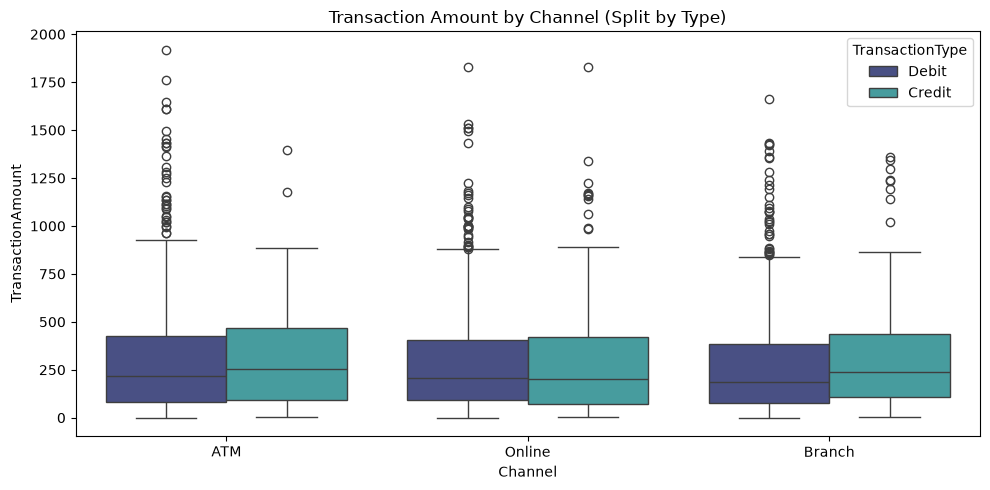

In [57]:
# Transaction Amount by Channel and Transaction Type
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Channel',
    y='TransactionAmount',
    hue='TransactionType',
    palette='mako'
)
plt.title("Transaction Amount by Channel (Split by Type)")
plt.tight_layout()
plt.show()

Across the channels , the transaction types and spending behavior is identical.

Since LoginAttempts > 1 is highly anomalous, see where those anomalies occur. Are the multiple attempts happening exclusively on the "Online" channel?

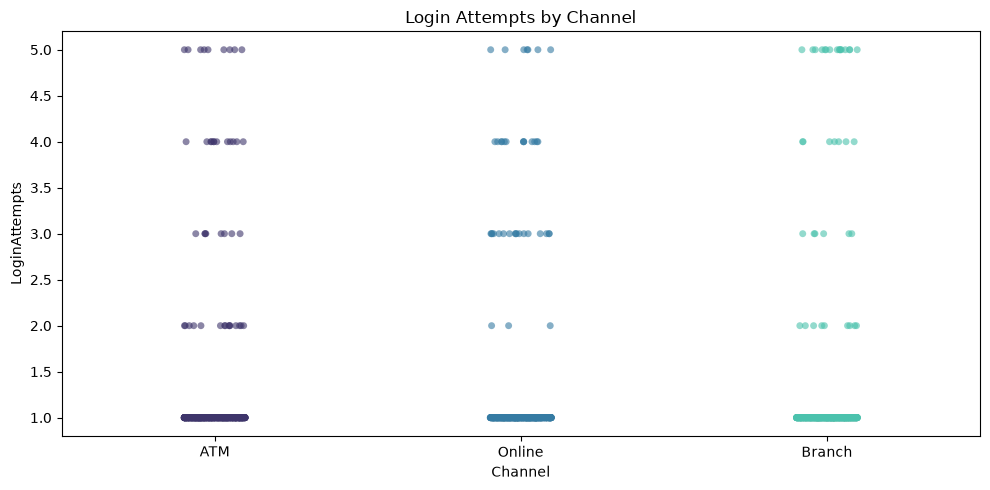

In [58]:
# Login Attempts by Channel
plt.figure(figsize=(10, 5))
sns.stripplot(
    data=df,
    x='Channel',
    y='LoginAttempts',
    hue='Channel',
    palette='mako',
    legend=False,
    jitter=True,
    alpha=0.6
)
plt.title("Login Attempts by Channel")
plt.tight_layout()
plt.show()

In real world , we would expect a strong correlation between the channel and failed login attempts.   

Online channels usually see the highest rate of failed attempts due to forgotten passwords, credential stuffing, or brute-force bot attacks.   

ATMs see a moderate amount due to forgotten PINs.   

Branches should logically have almost zero "login attempts" in the traditional sense, as identity is usually verified physically (e.g., handing over an ID or swiping a card with a teller).   



Are certain cities showing a disproportionately high volume of ATM transactions compared to Online? This could indicate a localized card-skimming operation.

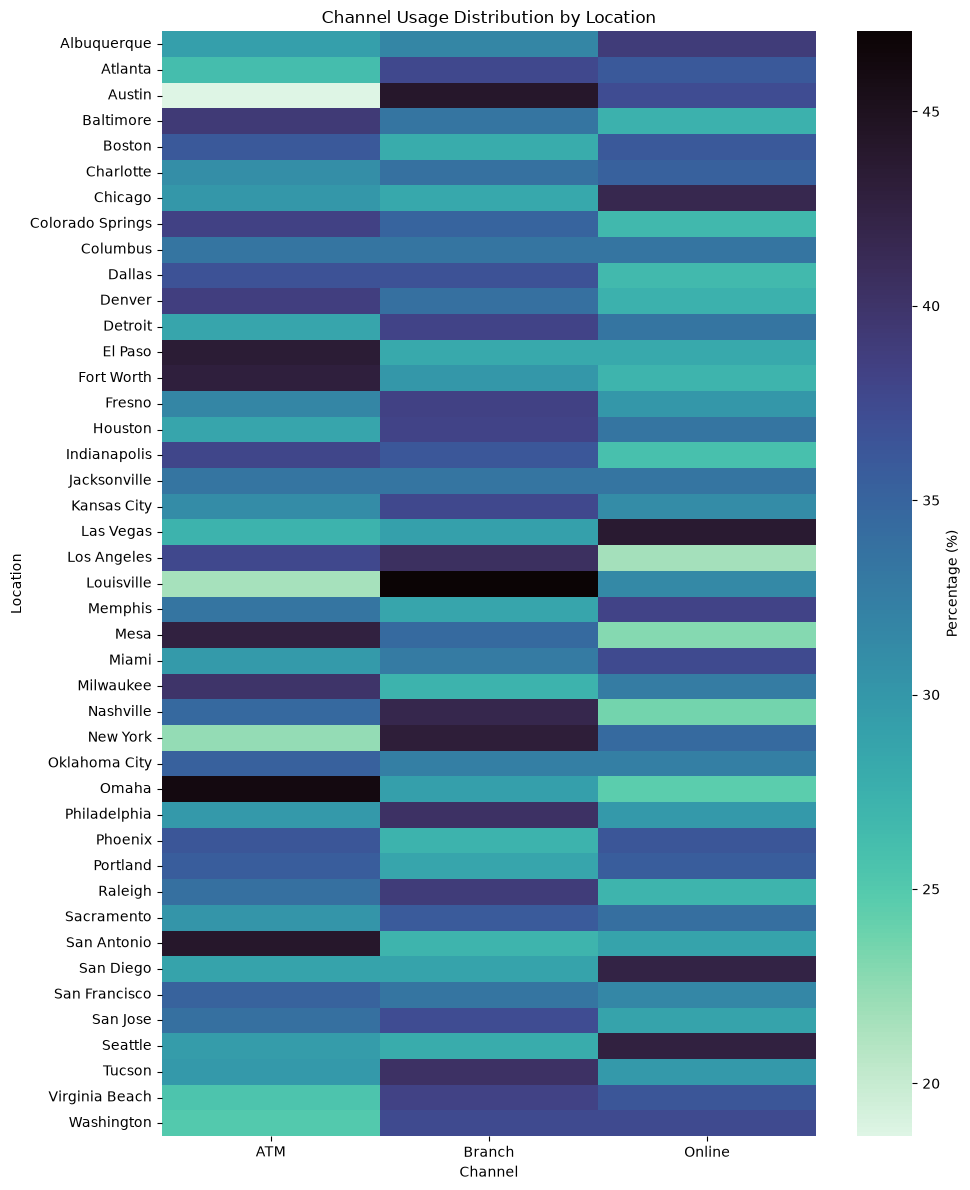

In [59]:
# 8. Location vs. Channel Heatmap
# Calculate percentages across rows (Location)
location_channel_ct = pd.crosstab(df['Location'], df['Channel'], normalize='index') * 100

plt.figure(figsize=(10, 12)) # Taller figure for high cardinality
sns.heatmap(
    location_channel_ct, 
    cmap="mako_r", # Reversed mako to keep dark colors for high percentages
    annot=False,   # Annotations turned off to avoid clutter
    cbar_kws={'label': 'Percentage (%)'}
)
plt.title("Channel Usage Distribution by Location")
plt.xlabel("Channel")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

Omaha, El Paso, and San Antonio are nearly pitch black, indicating disproportionately high ATM usage.  

Meanwhile, cities like Austin, Louisville, and New York are very pale green, indicating unusually low ATM usage.   


In real-world banking data, while you might see slight regional variations, digital adoption (Online banking) and ATM usage generally follow broader, smoother national trends.   


A decision tree algorithm (like XGBoost or Random Forest) might easily memorize this noise.


Feature Engineering Required: We should absolutely not use standard "one-hot encoding" for this column, as it will create dozens of noisy, unhelpful columns. To make Location useful, you should use Target Encoding (replacing the city name with the average historical fraud rate for that specific city) once you have your fraud labels. If the location column does not correlate with fraud at all, it might be safer to drop the column entirely to prevent the model from learning false geographic baselines.

if a single AccountID is suddenly spawning multiple new DeviceIDs or IP Addresses in a short timeframe, which is a classic indicator of account takeover.

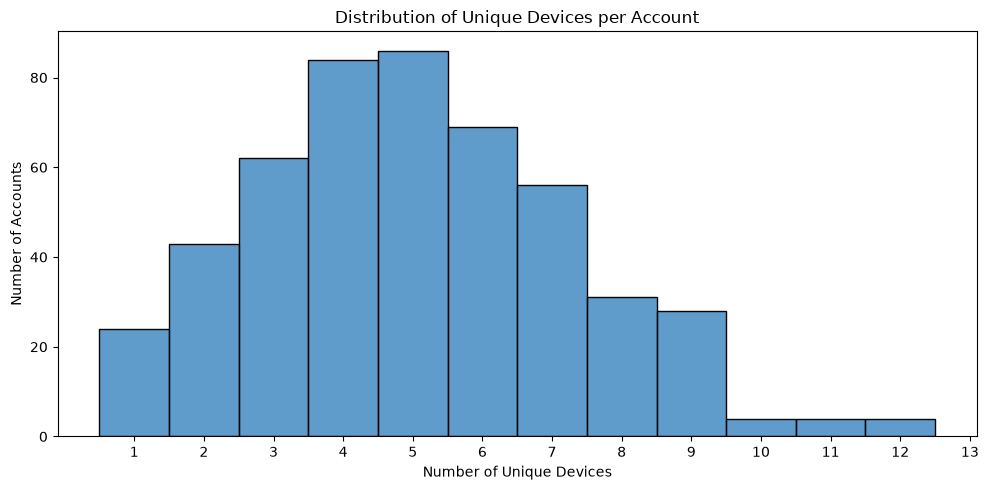

In [60]:
# 9. Cardinality Check: Unique Devices per Account
# Group by AccountID and count unique DeviceIDs
device_per_account = df.groupby('AccountID')['DeviceID'].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(
    device_per_account, 
    discrete=True, 
    color='#2b7bba' # Approximating a mako blue
)
plt.title("Distribution of Unique Devices per Account")
plt.xlabel("Number of Unique Devices")
plt.ylabel("Number of Accounts")
plt.xticks(range(1, device_per_account.max() + 2))
plt.tight_layout()
plt.show()

In this dataset, the "average" customer uses 5 different devices to access their bank account. This normal distribution centered around 5 is mathematically clean, which once again confirms this is a synthetic dataset where device IDs were likely assigned to accounts using a random distribution function rather than modeling actual human behavior.


### Temporal Analysis


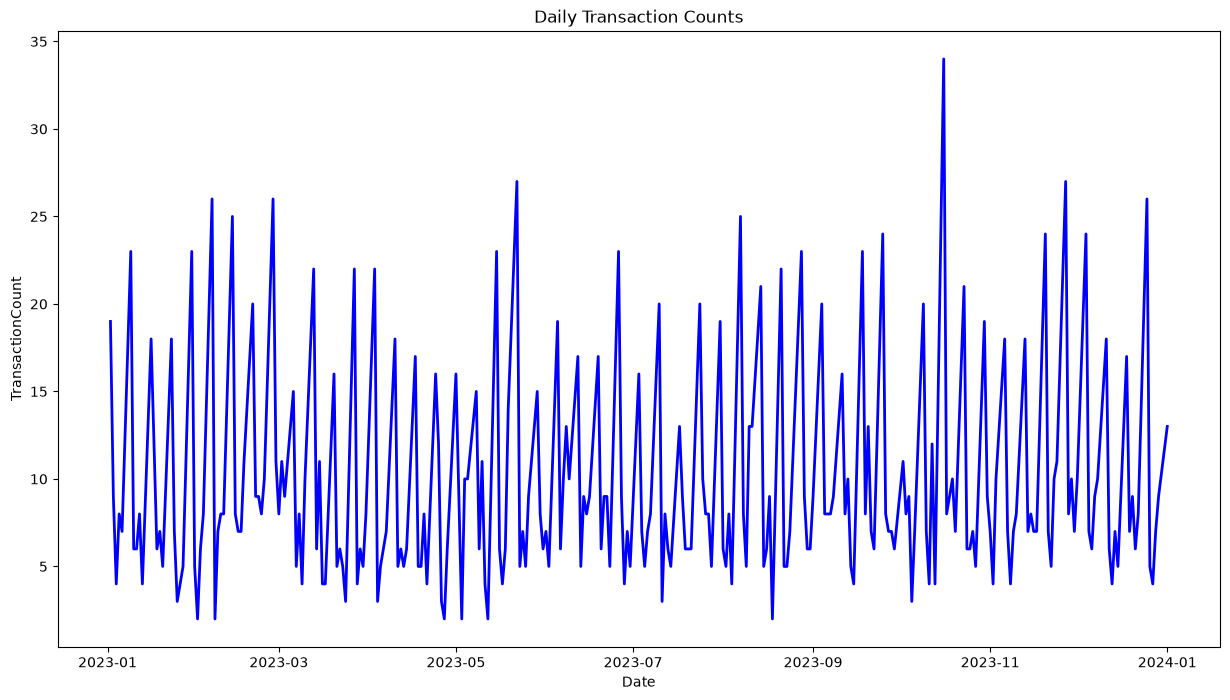

In [61]:
from datetime import datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionDay'] = df['TransactionDate'].dt.date
daily_counts = df.groupby('TransactionDay').size() #count gives count of each column in the dataframe
plt.figure(figsize=(15,8))
daily_counts.plot(title='Daily Transaction Counts', color='blue', linewidth=2)
plt.xlabel('Date')
plt.ylabel('TransactionCount')
plt.show()

In real-world financial data, macro-level transaction volumes are heavily influenced by human behavior and calendar events.

High transaction volumes on Fridays (paydays, weekend preparation) and significant dips on Sundays.

Massive spikes around late November (Black Friday) and December, followed by a drop in January.

A gradual upward slope over the year if the bank is acquiring new customers.

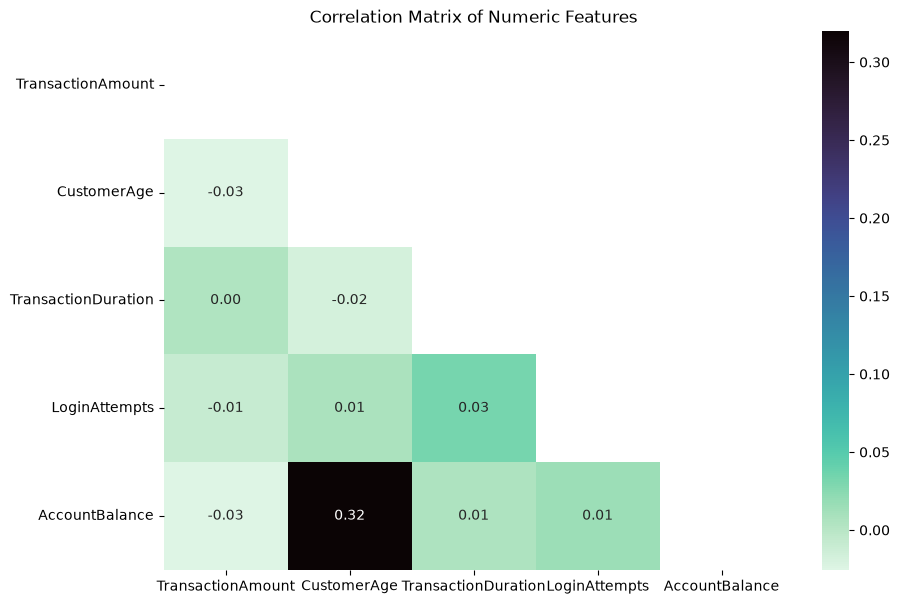

In [62]:
plt.figure(figsize=(10,7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='mako_r', fmt=".2f", mask=np.triu(corr))
plt.title("Correlation Matrix of Numeric Features")
plt.show()

This shows no correlation at all

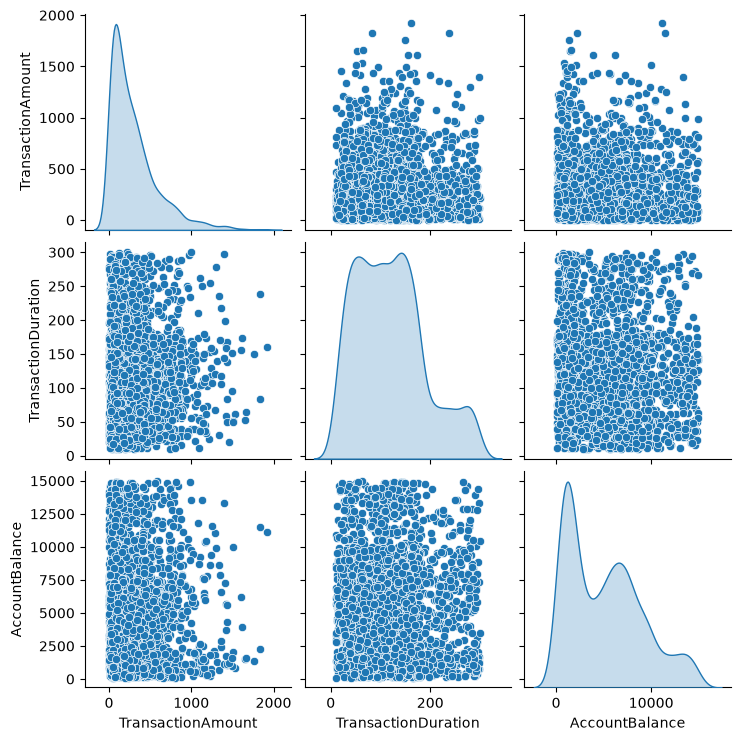

In [63]:
sns.pairplot(df[['TransactionAmount','TransactionDuration','AccountBalance']], diag_kind="kde")
plt.show()

# Feature Engineering

In [64]:
#converting into datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df['TransactionDay'] = df['TransactionDate'].dt.date

Feature 1: Time Since Last Transaction (Converted to Hours)   
We calculate the difference, get the total seconds, and divide by 3600 to get a float representing hours.  
A value of 0.05 means the transaction happened 3 minutes after the previous one

In [65]:
df['TimeSinceLastTx_Hours'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / 3600

Feature 2: Daily Account Volume    
We group by the Account AND the Date, then count the number of TransactionIDs.     
Using .transform('count') is crucial here—it broadcasts the total count back to every row.     
associated with that account, keeping your dataframe the exact same length.

In [66]:
df['DailyAccountVolume'] = df.groupby(['AccountID', 'TransactionDay'])['TransactionID'].transform('count')

Feature 3: The Utilization Ratio (from our scatter plot analysis)   
What percentage of the available balance is being drained?

In [67]:
df['UtilizationRatio'] = df['TransactionAmount'] / df['AccountBalance']

Feature 4: Daily Device Velocity  
How many times was this device used today?  

In [68]:
df['DailyDeviceVelocity'] = df.groupby(['DeviceID', 'TransactionDay'])['TransactionID'].transform('count')

In [69]:
columns_to_check = [
    'AccountID', 
    'TransactionAmount',
    'AccountBalance',
    'UtilizationRatio',
    'TimeSinceLastTx_Hours', 
    'DailyAccountVolume',
    'DailyDeviceVelocity'
]

print(df[columns_to_check].head())

  AccountID  TransactionAmount  AccountBalance  UtilizationRatio  \
0   AC00128              14.09         5112.21          0.002756   
1   AC00455             376.24        13758.91          0.027345   
2   AC00019             126.29         1122.35          0.112523   
3   AC00070             184.50         8569.06          0.021531   
4   AC00411              13.45         7429.40          0.001810   

   TimeSinceLastTx_Hours  DailyAccountVolume  DailyDeviceVelocity  
0          -13743.648333                   1                    1  
1          -11895.421111                   1                    1  
2          -11581.848889                   1                    1  
3          -13167.615278                   1                    1  
4           -9230.254167                   1                    1  


TimeSinceLastTx_Hours: If a user typically has 72+ hours between transactions, but suddenly executes a transaction with a TimeSinceLastTx_Hours of 0.02 (roughly 1 minute), the tree will flag the sudden speed run.

DailyAccountVolume: Because your baseline is synthetic and randomly distributed, most accounts will likely have a DailyAccountVolume of 1. If you inject a simulated brute-force attack where one AccountID has 15 transactions on a single TransactionDay, your model will use this column to catch it instantly.

UtilizationRatio: A TransactionAmount of $1,000 might look mathematically normal on its own. But if the AccountBalance is $1,050, the UtilizationRatio will evaluate to 0.95 (95% drain). The model will learn to associate ratios approaching 1.0 with high anomaly scores.

### Dropping unwanted columns

In [70]:
columns_to_drop = [
    'TransactionDate', 
    'PreviousTransactionDate', 
    'TransactionDay',
    'TransactionID', 
    'AccountID', 
    'DeviceID', 
    'IP Address', 
    'MerchantID'
]
df_model = df.drop(columns=columns_to_drop)

The Location column as a numeric measure of how "common" or "rare" a transaction's geographic origin is within the dataset.

In [71]:
# Calculate the frequency of each city
location_frequencies = df_model['Location'].value_counts()

# Map the frequencies back to the dataframe to replace the city names
df_model['Location_Freq'] = df_model['Location'].map(location_frequencies)

# Drop the original text-based 'Location' column
df_model = df_model.drop(columns=['Location'])

### Encoding

In [72]:
low_cardinality_cols = ['TransactionType', 'Channel', 'CustomerOccupation']

# Use get_dummies to convert text categories into binary (0 or 1) numeric columns
df_model = pd.get_dummies(df_model, columns=low_cardinality_cols, dtype=int)

In [73]:
print(f"Final dataset shape: {df_model.shape}")
print("\nFinal columns ready for modeling:")
print(df_model.columns.tolist())

Final dataset shape: (2512, 19)

Final columns ready for modeling:
['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TimeSinceLastTx_Hours', 'DailyAccountVolume', 'UtilizationRatio', 'DailyDeviceVelocity', 'Location_Freq', 'TransactionType_Credit', 'TransactionType_Debit', 'Channel_ATM', 'Channel_Branch', 'Channel_Online', 'CustomerOccupation_Doctor', 'CustomerOccupation_Engineer', 'CustomerOccupation_Retired', 'CustomerOccupation_Student']


Scaling for PCA and t-SNE

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_model.columns)


## PCA

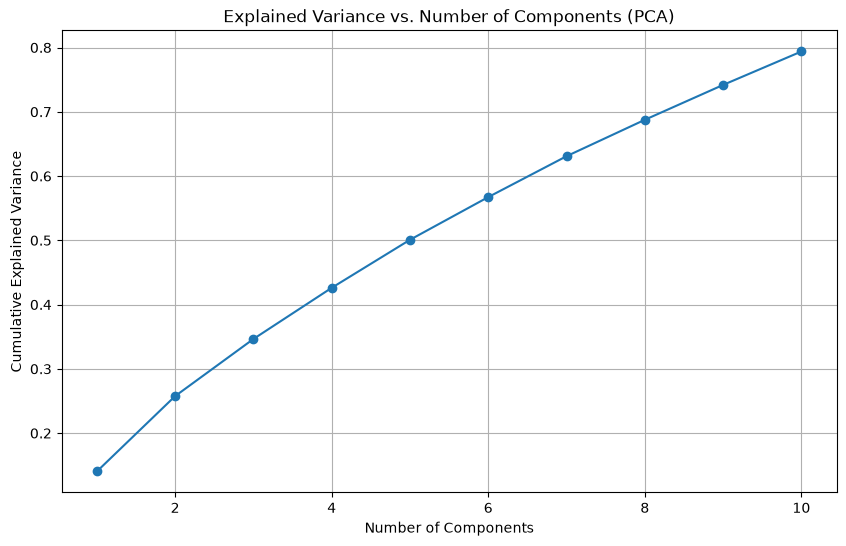

In [75]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# PCA
n_components = min(10, len(df_model.columns))
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(df_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components (PCA)")
plt.grid(True)
plt.show()



This plot shows that dataset's features are almost completely independent of one another.  
PCA struggles to compress the data without losing information

## t-SNE


Applying t-SNE for visualization...


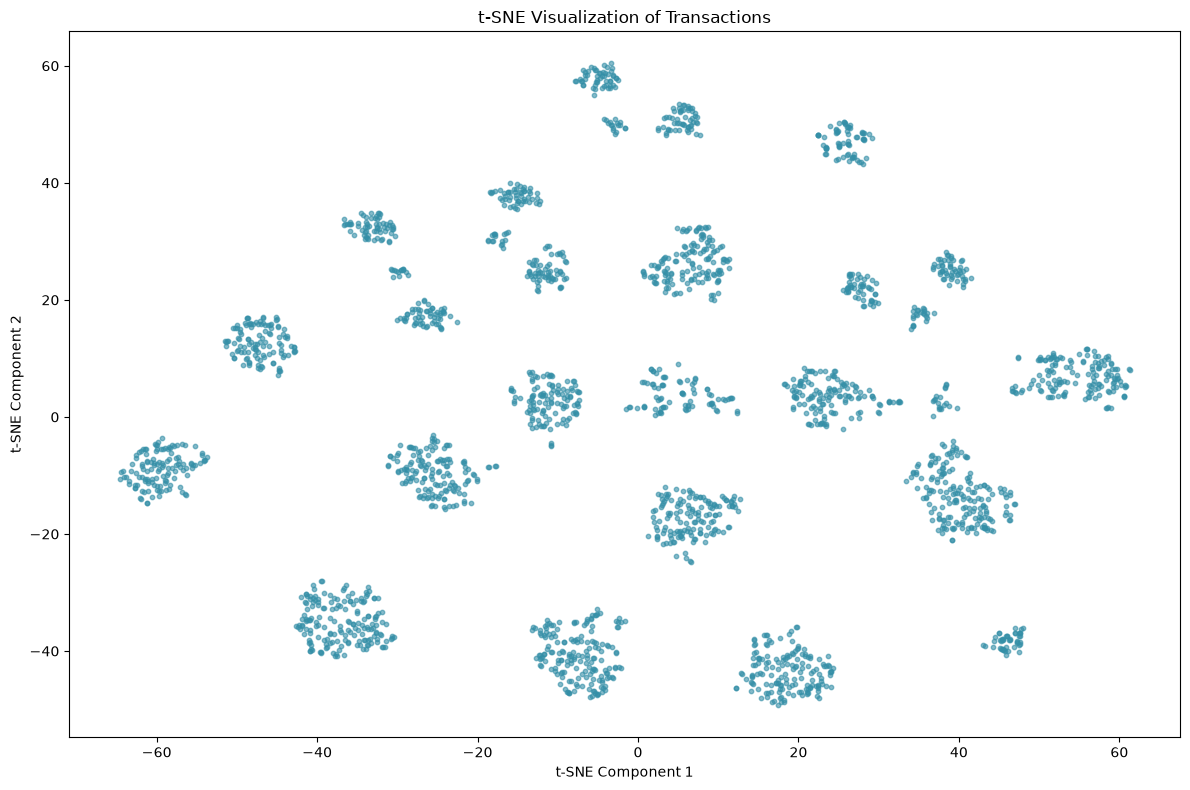

In [76]:
# t-SNE
print("\nApplying t-SNE for visualization...")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

tsne_results = tsne.fit_transform(df_scaled)

plt.figure(figsize=(12, 8))

plt.scatter(
    tsne_results[:, 0],
    tsne_results[:, 1],
    s=10,
    alpha=0.6,
    color=sns.color_palette("mako")[3]
)

plt.title("t-SNE Visualization of Transactions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.tight_layout()
plt.show()

The "Archipelago" Effect: Instead of a single continuous cloud (which is typical for organic human behavior), the data has fractured into dozens of distinct, isolated "islands." 

Because our continuous numerical features (like TransactionAmount and CustomerAge) are entirely independent, t-SNE cannot use them to build a meaningful, continuous spatial manifold. Instead, the algorithm has latched onto the only rigid mathematical structure left in we scaled dataset: the one-hot encoded categorical variables.

hink about the categorical variables that we  encoded:

- Channel has 3 options (ATM, Branch, Online).  
  
- CustomerOccupation has 4 options (Doctor, Student, Retired, Engineer).  
  
- TransactionType has 2 options (Credit, Debit).
  
If we multiply those combinations ($3 \times 4 \times 2 = 24$), we get exactly 24 distinct subgroups. If we count the distinct clusters in we t-SNE plot, we will see roughly 24 main islands. The t-SNE algorithm has simply sorted we dataset into these exact categorical buckets, while the random numerical noise dictates where a point sits within its assigned bucket.

# Anomaly Detection Models

In [77]:
def plot_anomalies(tsne_results, df, label_col, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=tsne_results[:, 0],
        y=tsne_results[:, 1],
        hue=df[label_col],
        palette='coolwarm',
        alpha=0.7
    )
    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="Anomaly", loc='upper right')
    plt.show()

# Isolation Forest

In purely unsupervised anomaly detection, traditional hyperparameter tuning via automated GridSearch is not possible out-of-the-box. Without a labeled validation set, there is no mathematical "right answer" to optimize for.  


set the parameters based on domain knowledge and heuristic evaluation.  

Training Isolation Forest...


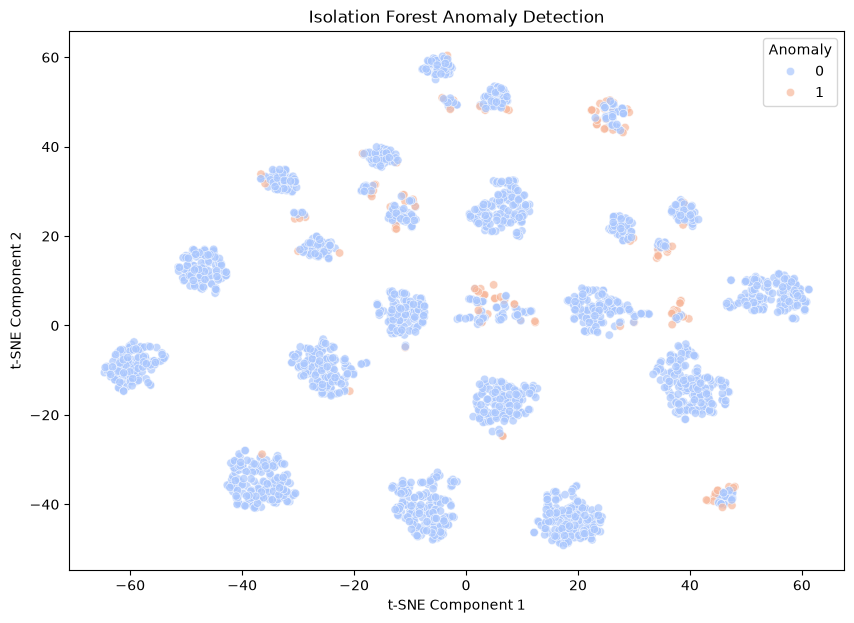

In [78]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Isolation Forest directly with chosen heuristics
# Contamination is the critical lever here. Start at 2% or 5%.
iso_forest = IsolationForest(
    n_estimators=200, 
    contamination=0.05, 
    max_samples='auto', 
    random_state=42,
    n_jobs=-1
)

# 2. Fit and Predict
print("Training Isolation Forest...")
iso_forest.fit(df_scaled_df)

# Generate labels (1 for inlier, -1 for outlier) and raw anomaly scores
df_model["IF_Anomaly"] = iso_forest.predict(df_scaled_df)  
df_model["IF_Score"] = iso_forest.decision_function(df_scaled_df)  

# 3. Map the outputs to a standard boolean/binary format (1 = Anomaly, 0 = Normal)
df_model["IF_Anomaly"] = df_model["IF_Anomaly"].map({1: 0, -1: 1})

# 4. Plot the results onto your t-SNE projection
plot_anomalies(tsne_results, df_model, 'IF_Anomaly', "Isolation Forest Anomaly Detection")

In [79]:
anomaly_count = df_model['IF_Anomaly'].sum()
total_count = len(df_model)
print(f"Total Transactions: {total_count}")
print(f"Anomalies Detected: {anomaly_count} ({(anomaly_count/total_count)*100:.2f}%)")

Total Transactions: 2512
Anomalies Detected: 126 (5.02%)


Because the global dataset is heavily dominated by Debit transactions, any dense pocket or subgroup where Credit becomes the majority behavior is mathematically rare in the context of the whole dataset. The Isolation Forest recognized that this particular categorical combination deviates significantly from the global majority trend, requiring fewer splits to isolate, and thus flagged the entire cluster as an anomaly.

In [80]:
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# 1. Scale the data using RobustScaler
print("Scaling data with RobustScaler...")
robust_scaler = RobustScaler()
df_robust_scaled = robust_scaler.fit_transform(df_model)

# Convert back to dataframe for easier handling (optional but good for tracking)
df_robust_scaled_df = pd.DataFrame(df_robust_scaled, columns=df_model.columns)

# 2. Initialize LOF
# n_neighbors: Typically set between 20 (local focus) and 50 (broader focus).
# contamination: Set to your expected anomaly rate (e.g., 5%).
lof = LocalOutlierFactor(
    n_neighbors=20, 
    contamination=0.05, 
    metric='euclidean',
    n_jobs=-1
)

# 3. Fit and Predict
# LOF calculates the labels in one step for outlier detection
print("Training LOF and predicting anomalies...")
lof_labels = lof.fit_predict(df_robust_scaled_df)

# LOF returns 1 for inliers and -1 for outliers. 
# We map this to 0 (normal) and 1 (anomaly) for consistency.
df_model['LOF_Anomaly'] = np.where(lof_labels == -1, 1, 0)

# Optional: Extract the raw negative outlier factor scores (lower is more anomalous)
df_model['LOF_Score'] = lof.negative_outlier_factor_

# 4. Check the distribution
print("\nLOF Anomaly Counts:")
print(df_model['LOF_Anomaly'].value_counts())


Scaling data with RobustScaler...
Training LOF and predicting anomalies...

LOF Anomaly Counts:
LOF_Anomaly
0    2386
1     126
Name: count, dtype: int64


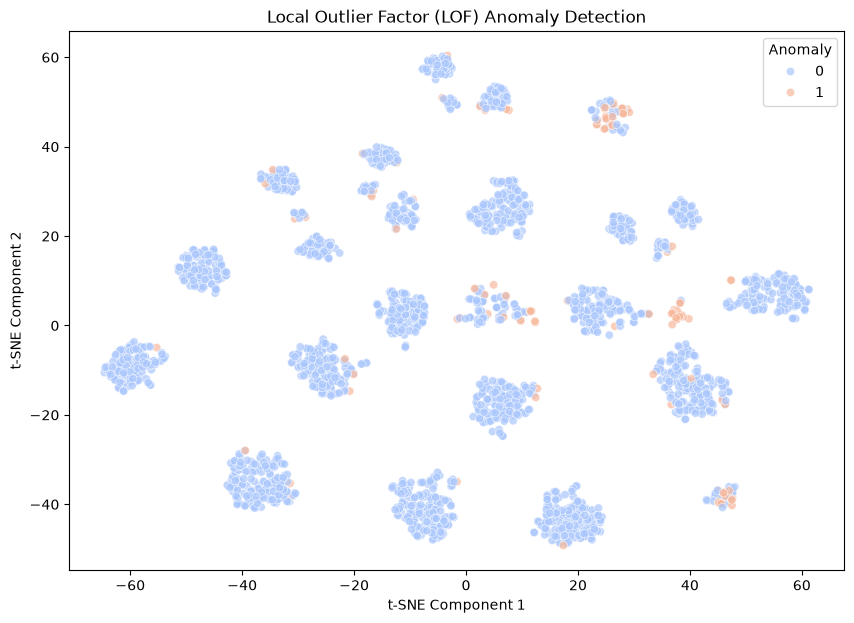

In [81]:
plot_anomalies(tsne_results, df_model, 'LOF_Anomaly', "Local Outlier Factor (LOF) Anomaly Detection")